# CC_Plot_strip_IS_4regime

Task 2: Ice sheet stackplot with **4 regimes** (all 90 members), site LA.

Regimes determined per member per time step:

| Regime | Condition |
|--------|-----------|
| Aerial + ice | GSL ≥ −28 m AND ice_sheet ≥ 1 |
| Aerial + no ice | GSL ≥ −28 m AND ice_sheet < 1 |
| Under sea + ice | GSL < −28 m AND ice_sheet ≥ 1 |
| Under sea + no ice | GSL < −28 m AND ice_sheet < 1 |

GSL from `emul_inputs_{scenario}.{member}.updated.res`, column `ice`.

Generated by Claude Code (CC_ prefix rule).
Source notebook: `Plot_strip_IS.ipynb`

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
variables  = ["temp", "precip", "evap", "soiltemp", "sm",
              "snowdepth", "LAI_PFT", "windspeed", "iceconc", "ice_sheet"]
var        = 9          # ice_sheet
site       = "_LA"
ice_thresh = 1.0        # values >= threshold → ice present
gsl_thresh = -28.0      # m; below this → under sea

scenarios  = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]
scen_labels = ["Natural", "SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5", "10,000 PgC"]
n_members  = 90

# Colours for the 4 regimes
# Stacking order (bottom→top): aerial_noice | aerial_ice | undersea_noice | undersea_ice
COLOR_AERIAL_ICE      = 'grey'
COLOR_AERIAL_NOICE    = 'green'
COLOR_UNDERSEA_ICE    = 'white'
COLOR_UNDERSEA_NOICE  = 'skyblue'

ice_data_path = "site_data/"

gsl_data_path = "../2_GSL_model/results/emul_inputs_updatedCO2/"

out_path = "plots/ice_sheet_site_LA_4regime_allMembers.png"

In [46]:
# ── Load ice_sheet data ───────────────────────────────────────────────────────
# Shape per scenario: (n_members, n_timesteps) = (90, 1001)
ice_all = {}   # {scen_idx: ndarray (90, 1001)}

for scen_idx, scen in enumerate(scenarios):
    fpath = f"{ice_data_path}site{site}/{variables[var]}_{scen}_site{site}.txt"
    print(f"Loading ice_sheet [{scen}] ...")
    ice_all[scen_idx] = np.loadtxt(fpath)   # (90, 1001)
    print(f"  shape: {ice_all[scen_idx].shape}")

Loading ice_sheet [natural] ...
  shape: (90, 1001)
Loading ice_sheet [SSP126] ...
  shape: (90, 1001)
Loading ice_sheet [SSP245] ...
  shape: (90, 1001)
Loading ice_sheet [SSP370] ...
  shape: (90, 1001)
Loading ice_sheet [SSP585] ...
  shape: (90, 1001)
Loading ice_sheet [10000PGC] ...
  shape: (90, 1001)


In [47]:
# ── Load GSL data ─────────────────────────────────────────────────────────────
# Read 90 res files per scenario; extract column 'ice' (= GSL, m)
# Shape per scenario: (n_members, n_timesteps) = (90, 1001)
gsl_all = {}   # {scen_idx: ndarray (90, 1001)}

for scen_idx, scen in enumerate(scenarios):
    print(f"Loading GSL [{scen}] ...")
    gsl_members = []
    for m in range(1, n_members + 1):
        fpath = f"{gsl_data_path}emul_inputs_{scen}.{m}.updated.res"
        df = pd.read_csv(fpath, sep=r'\s+', header=0)
        gsl_members.append(df['ice'].values)   # 1001 values
    gsl_all[scen_idx] = np.stack(gsl_members, axis=0)   # (90, 1001)
    print(f"  shape: {gsl_all[scen_idx].shape}, "
          f"GSL range [{gsl_all[scen_idx].min():.1f}, {gsl_all[scen_idx].max():.1f}] m")

Loading GSL [natural] ...
  shape: (90, 1001), GSL range [-135.8, 10.0] m
Loading GSL [SSP126] ...
  shape: (90, 1001), GSL range [-142.7, 15.0] m
Loading GSL [SSP245] ...
  shape: (90, 1001), GSL range [-139.2, 17.9] m
Loading GSL [SSP370] ...
  shape: (90, 1001), GSL range [-136.9, 24.0] m
Loading GSL [SSP585] ...
  shape: (90, 1001), GSL range [-138.4, 24.0] m
Loading GSL [10000PGC] ...
  shape: (90, 1001), GSL range [-133.4, 24.0] m


In [48]:
# ── Classify into 4 regimes per time step ─────────────────────────────────────
# For each scenario: count members in each regime at every time step
# Result arrays shape: (n_timesteps,) with counts 0..90, sum = 90 at every step

def classify_regimes(ice_mat, gsl_mat, ice_thr=1.0, gsl_thr=-28.0):
    """Return 4 count arrays of shape (n_timesteps,)."""
    ice_present = ice_mat >= ice_thr      # bool (90, 1001)
    undersea    = gsl_mat <  gsl_thr      # bool (90, 1001)

    aerial_ice      = np.sum( ~undersea &  ice_present, axis=0)  # (1001,)
    aerial_noice    = np.sum( ~undersea & ~ice_present, axis=0)
    undersea_ice    = np.sum(  undersea &  ice_present, axis=0)
    undersea_noice  = np.sum(  undersea & ~ice_present, axis=0)

    # Sanity check
    total = aerial_ice + aerial_noice + undersea_ice + undersea_noice
    assert np.all(total == ice_mat.shape[0]), "Regime counts do not sum to n_members!"
    return aerial_ice, aerial_noice, undersea_ice, undersea_noice

regimes = {}   # {scen_idx: (a_ice, a_noice, us_ice, us_noice)}
for scen_idx in range(len(scenarios)):
    regimes[scen_idx] = classify_regimes(
        ice_all[scen_idx], gsl_all[scen_idx],
        ice_thr=ice_thresh, gsl_thr=gsl_thresh
    )
    a_ice, a_noice, us_ice, us_noice = regimes[scen_idx]
    print(f"{scen_labels[scen_idx]:12s} — overall % time: "
          f"aerial+ice={a_ice.mean()/n_members*100:.1f}%  "
          f"aerial+noice={a_noice.mean()/n_members*100:.1f}%  "
          f"undersea+ice={us_ice.mean()/n_members*100:.1f}%  "
          f"undersea+noice={us_noice.mean()/n_members*100:.1f}%")

Natural      — overall % time: aerial+ice=0.0%  aerial+noice=25.9%  undersea+ice=0.0%  undersea+noice=74.1%
SSP1-2.6     — overall % time: aerial+ice=0.0%  aerial+noice=29.9%  undersea+ice=0.0%  undersea+noice=70.1%
SSP2-4.5     — overall % time: aerial+ice=0.0%  aerial+noice=37.5%  undersea+ice=0.0%  undersea+noice=62.5%
SSP3-7.0     — overall % time: aerial+ice=0.0%  aerial+noice=50.5%  undersea+ice=0.0%  undersea+noice=49.5%
SSP5-8.5     — overall % time: aerial+ice=0.0%  aerial+noice=58.6%  undersea+ice=0.0%  undersea+noice=41.3%
10,000 PgC   — overall % time: aerial+ice=0.0%  aerial+noice=67.9%  undersea+ice=0.0%  undersea+noice=32.1%


Saved to: plots/ice_sheet_site_LA_4regime_allMembers.png


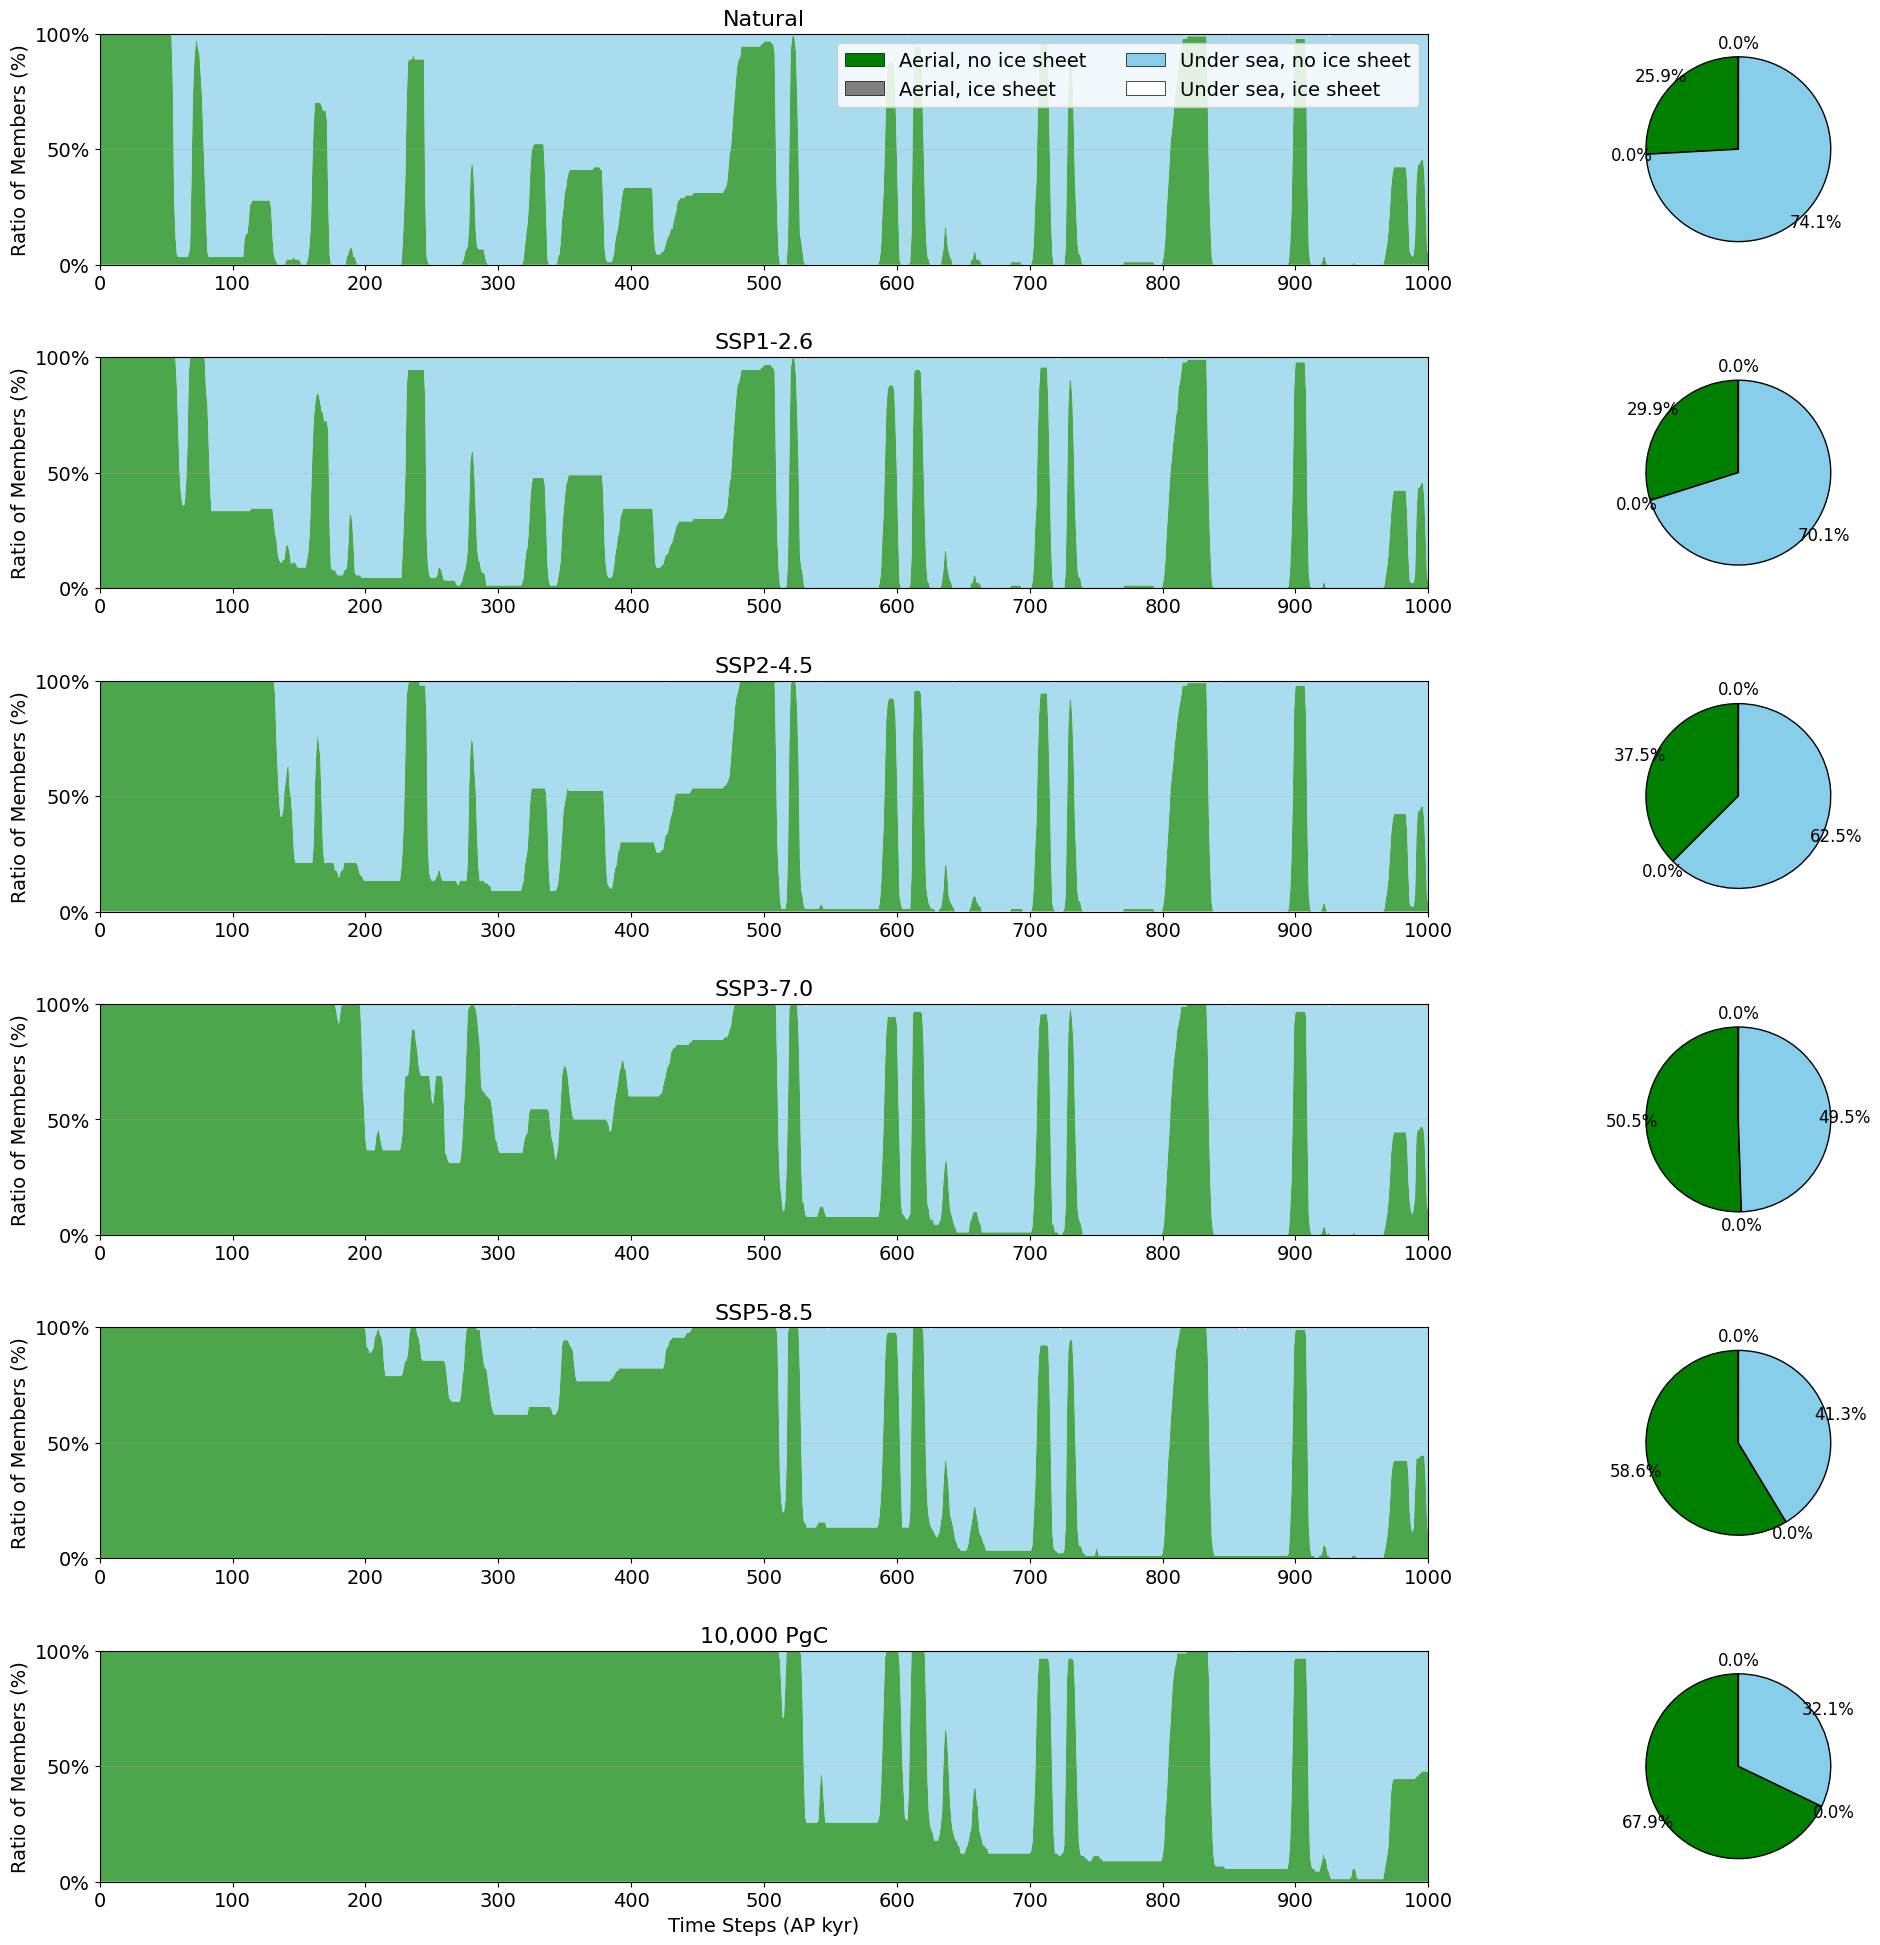

In [49]:
# ── Plot ─────────────────────────────────────────────────────────────────────
n_scen      = len(scenarios)
n_timesteps = ice_all[0].shape[1]            # 1001
time_steps  = np.arange(n_timesteps)

fig = plt.figure(figsize=(24, 4 * n_scen))
gs  = GridSpec(n_scen, 2, figure=fig,
               width_ratios=[3, 1], hspace=0.4, wspace=0.1)

STACK_ORDER  = ['aerial_noice', 'aerial_ice', 'undersea_noice', 'undersea_ice']
STACK_COLORS = [COLOR_AERIAL_NOICE, COLOR_AERIAL_ICE,
                COLOR_UNDERSEA_NOICE, COLOR_UNDERSEA_ICE]
STACK_LABELS = ['Aerial, no ice sheet',
                'Aerial, ice sheet',
                'Under sea, no ice sheet',
                'Under sea, ice sheet']

for scen_idx, scen_label in enumerate(scen_labels):
    a_ice, a_noice, us_ice, us_noice = regimes[scen_idx]
    counts = {
        'aerial_noice'   : a_noice,
        'aerial_ice'     : a_ice,
        'undersea_noice' : us_noice,
        'undersea_ice'   : us_ice,
    }
    pct = {k: v / n_members * 100 for k, v in counts.items()}

    # ── Left: stacked area ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[scen_idx, 0])
    ax1.stackplot(
        time_steps,
        *[pct[k] for k in STACK_ORDER],
        colors=STACK_COLORS,
        alpha=0.7,
        edgecolor='none'
    )

    ax1.set_xlim(0, 1000)
    ax1.set_xticks(time_steps[::100])
    ax1.set_xticklabels(time_steps[::100], fontsize=14)
    ax1.set_ylim(0, 100)
    ax1.set_yticks([0, 50, 100])
    ax1.set_yticklabels(['0%', '50%', '100%'], fontsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_ylabel('Ratio of Members (%)', fontsize=14)
    ax1.set_title(scen_label, fontsize=16)
    ax1.grid(axis='y', alpha=0.3)

    if scen_idx == n_scen - 1:
        ax1.set_xlabel('Time Steps (AP kyr)', fontsize=14)

    if scen_idx == 0:
        handles = [
            mpatches.Patch(facecolor=c, edgecolor='black', linewidth=0.5, label=l)
            for c, l in zip(STACK_COLORS, STACK_LABELS)
        ]
        ax1.legend(handles=handles, loc='upper right', fontsize=14,
                   framealpha=0.85, ncol=2)

    # ── Right: pie chart (time-integrated proportions) ─────────────────────
    # pctdistance > 1 → labels outside wedge for thin slices
    ax2 = fig.add_subplot(gs[scen_idx, 1])
    pie_totals = [counts[k].sum() for k in STACK_ORDER]
    ax2.pie(
        pie_totals,
        colors=STACK_COLORS,
        autopct='%1.1f%%',
        pctdistance=1.15,
        startangle=90,
        textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )

plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved to: {out_path}")
plt.show()